# DATE3 实验5：PIVOT（MemDomain）动态预取协同优化

本实验在 MoDSE 上扫描 8 个 seed Window 与 4 个 seed Chunk，共 32 组配置。
每组均包含五个可实现对照方案和一个正式方案。实验依次回答：

1. 固定预取在静态/动态映射下是否仍对 Window×Chunk 敏感；
2. PIVOT（即 MemDomain）的在线 Chunk、Window、Bank-group 联合选择能否优于五个可实现对照；
3. Coverage/Accuracy 反馈、回退、incumbent guard 与策略消融是否真正提供证据。

这里的 Window/Chunk 是 PIVOT 的初始种子，不是其运行期间必须保持不变的最终值。


In [13]:
from pathlib import Path
import json
import os

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'fig' else Path.cwd().resolve()
# Jupyter/VS Code 有时会把 HOME 下的 Matplotlib 缓存目录挂成只读，
# 导致 Run All 卡在第一个绘图单元。在导入 matplotlib 前显式使用仓库内可写目录。
MPL_CACHE = ROOT / 'outputs/DATE3/.matplotlib'
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

OUT = ROOT / 'outputs/DATE3'
FIG = ROOT / 'fig/DATE3'
FIG.mkdir(parents=True, exist_ok=True)
WINDOWS = [0, 1, 2, 4, 8, 16, 32, 64]
CHUNKS = [1, 2, 4, 8]
POLICIES = ['Static-555-NoPF', 'Static-Opt-NoPF', 'Dynamic-NoPF',
            'Static-Opt-FixedPF', 'Dynamic-FixedPF', 'PIVOT']
BASELINES = POLICIES[:-1]

source = OUT / 'exp5/joint_prefetch.csv'
ablation_source = OUT / 'exp5/pivot_ca_ablation.csv'
calibration_source = OUT / 'exp5/prefetch_calibration.csv'
selection_source = OUT / 'exp5/deployable_selection.csv'
cross_model_source = OUT / 'exp7/end_to_end_summary.csv'
assert source.exists(), source
assert ablation_source.exists(), ablation_source
assert calibration_source.exists(), calibration_source
assert selection_source.exists(), selection_source
assert cross_model_source.exists(), cross_model_source
d = pd.read_csv(source)
ablation = pd.read_csv(ablation_source)
calibration = pd.read_csv(calibration_source)
deployable = pd.read_csv(selection_source).set_index('policy_name')
cross_model = pd.read_csv(cross_model_source)
assert len(d) == len(WINDOWS) * len(CHUNKS) * len(POLICIES)
assert set(d.policy_name) == set(POLICIES)
assert sorted(d.window.unique()) == WINDOWS
assert sorted(d.chunk_tiles.unique()) == CHUNKS
assert not d.duplicated(['window', 'chunk_tiles', 'policy_name']).any()
assert set(ablation.variant) == {
    'full', 'accuracy_only', 'coverage_only', 'both_constraints',
    'without_bank_pressure', 'without_dynamic_chunk',
    'without_dynamic_window', 'without_quality'
}
assert set(deployable.index) == {'Static-Opt-FixedPF', 'Dynamic-FixedPF'}
assert (~deployable.test_trace_visible_during_selection.astype(bool)).all()

def grid(policy, field='total_cycles'):
    return d[d.policy_name.eq(policy)].pivot(
        index='window', columns='chunk_tiles', values=field
    ).reindex(WINDOWS, columns=CHUNKS)

def heat(ax, frame, title, cmap='RdYlGn', center=None, fmt='.1f'):
    values = frame.to_numpy(dtype=float)
    if center is None:
        image = ax.imshow(values, aspect='auto', cmap=cmap)
    else:
        lo, hi = float(np.nanmin(values)), float(np.nanmax(values))
        if lo < center < hi:
            norm = TwoSlopeNorm(vmin=lo, vcenter=center, vmax=hi)
            image = ax.imshow(values, aspect='auto', cmap=cmap, norm=norm)
        else:
            image = ax.imshow(values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(frame.columns)), frame.columns)
    ax.set_yticks(range(len(frame.index)), frame.index)
    ax.set_xlabel('Fixed Chunk (tiles/request)'); ax.set_ylabel('Fixed Window')
    ax.set_title(title)
    threshold = (np.nanmin(values) + np.nanmax(values)) / 2
    for i in range(len(frame.index)):
        for j in range(len(frame.columns)):
            value = values[i, j]
            ax.text(j, i, format(value, fmt), ha='center', va='center',
                    fontsize=8, color='white' if value < threshold else 'black')
    plt.colorbar(image, ax=ax, shrink=.84)

def save_and_show(fig, stem):
    # Save deterministically and avoid a blocking GUI plt.show() call.
    pdf = FIG / f'{stem}.pdf'
    png = FIG / f'{stem}.png'
    fig.savefig(pdf, bbox_inches='tight')
    fig.savefig(png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    try:
        from IPython.display import Image, display as ipy_display
    except ImportError:
        return
    ipy_display(Image(filename=str(png)))

print(f'Loaded {len(d)} test-grid rows, {len(calibration)} calibration rows, '
      f'{len(ablation)} ablation rows, and {len(cross_model)} existing '
      'four-model end-to-end rows.')


Loaded 192 test-grid rows, 112 calibration rows, 8 ablation rows, and 24 existing four-model end-to-end rows.


## 5.1 固定预取对参数敏感

数值是固定预取相对对应 NoPF 的周期下降百分比：正值为加速、负值为退化。
两幅图的区别仅为 Bank 映射方式，预取参数完全相同。本测试轨迹上固定预取没有造成
端到端退化，但收益从0变化到20%以上，仍说明一个冻结参数不能持续匹配不同阶段；
“固定预取可能造成退化”的直接证据由实验3提供，实验5不重复承担该结论。


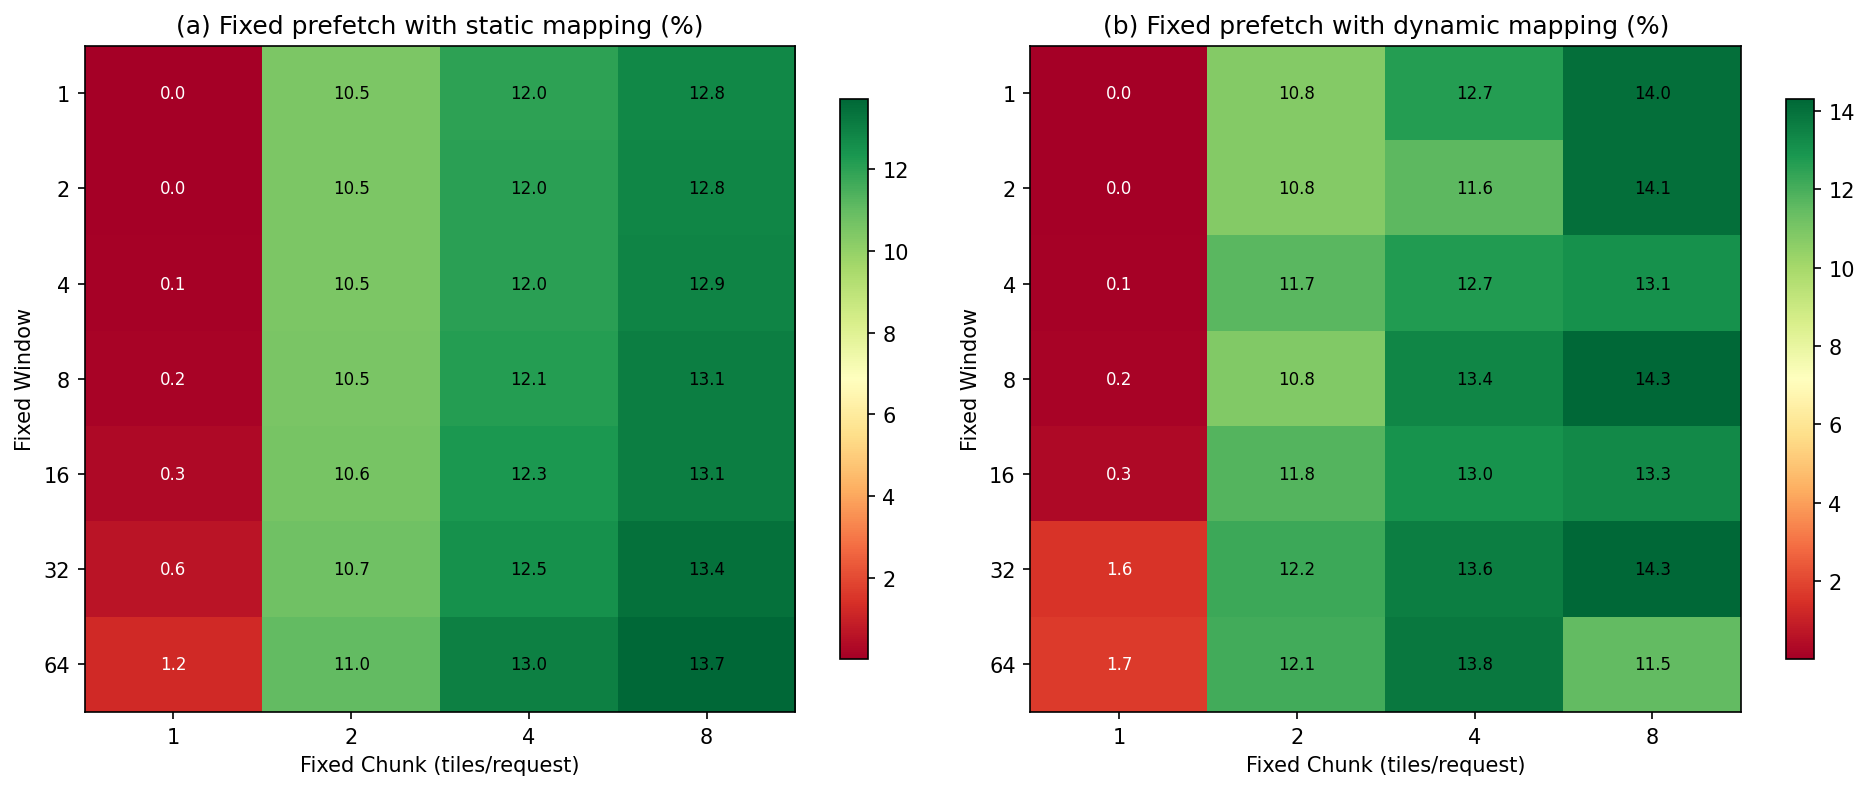

Static-mapping harmful points: 0 / 28
Dynamic-mapping harmful points: 0 / 28
Static fixed-prefetch range: 0.02% to 13.72%
Dynamic fixed-prefetch range: 0.02% to 14.31%
Static fixed-parameter sensitivity span: 13.70 percentage points
Dynamic fixed-parameter sensitivity span: 14.29 percentage points


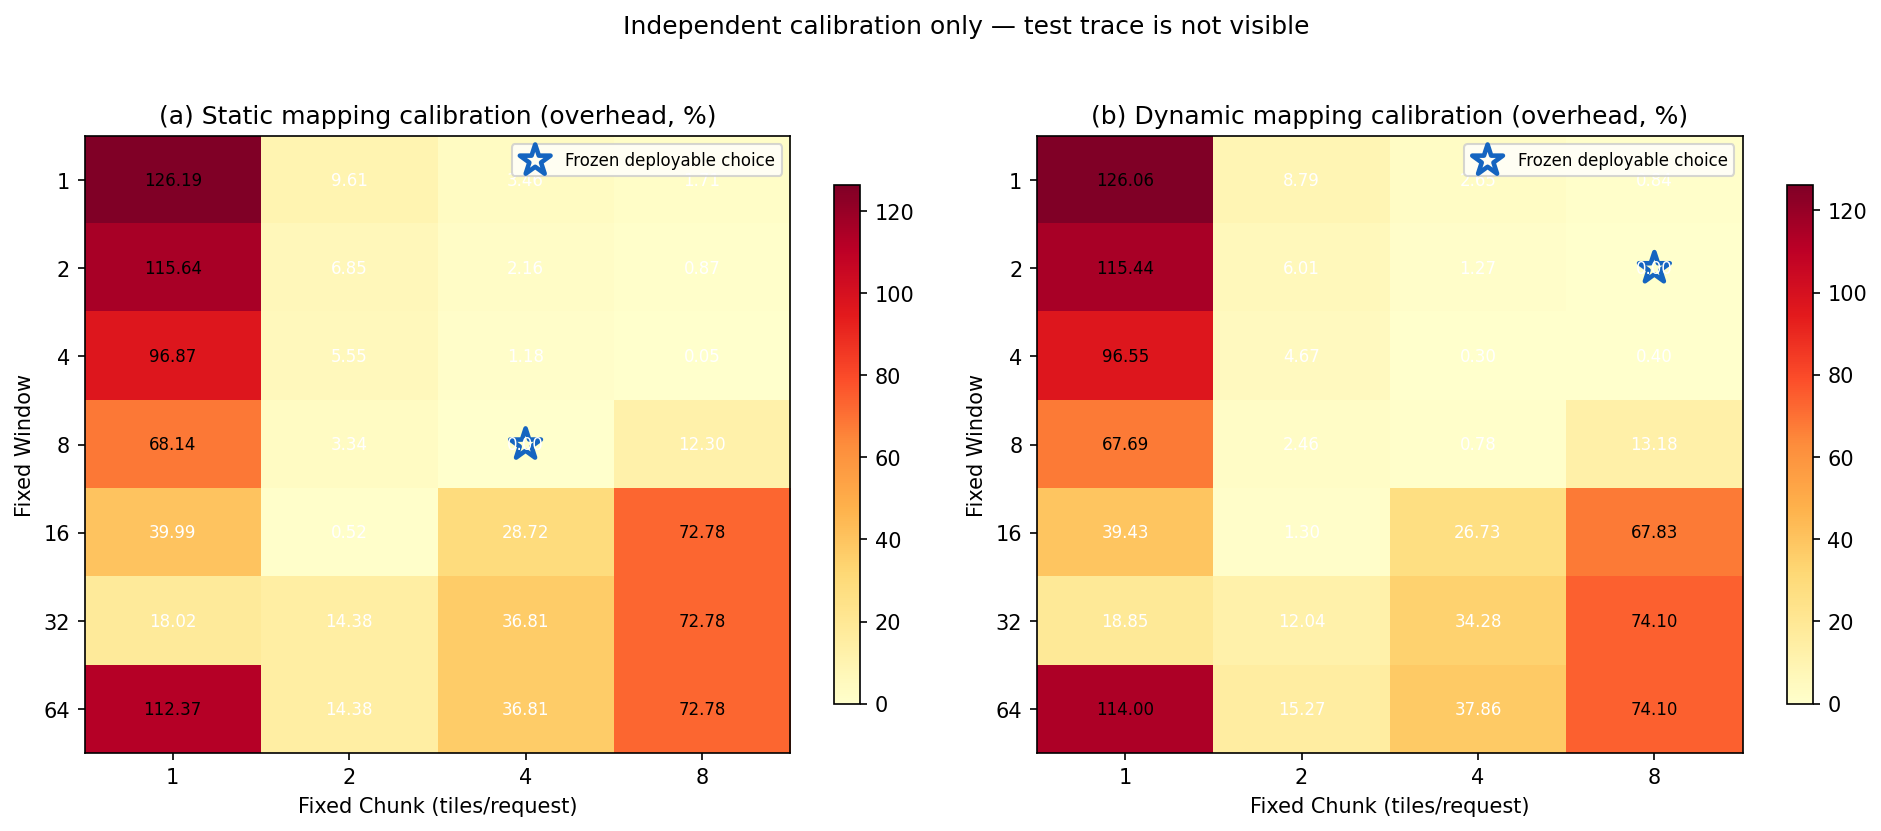

In [14]:
static_pf_gain = ((1 - grid('Static-Opt-FixedPF') / grid('Static-Opt-NoPF')) * 100).reindex(WINDOWS[1:])
dynamic_pf_gain = ((1 - grid('Dynamic-FixedPF') / grid('Dynamic-NoPF')) * 100).reindex(WINDOWS[1:])
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
heat(axes[0], static_pf_gain, '(a) Fixed prefetch with static mapping (%)',
     cmap='RdYlGn', center=0)
heat(axes[1], dynamic_pf_gain, '(b) Fixed prefetch with dynamic mapping (%)',
     cmap='RdYlGn', center=0)
fig.tight_layout(); save_and_show(fig, 'exp5_prefetch_tradeoff')
print('Static-mapping harmful points:', int((static_pf_gain < 0).sum().sum()), '/ 28')
print('Dynamic-mapping harmful points:', int((dynamic_pf_gain < 0).sum().sum()), '/ 28')
print(f'Static fixed-prefetch range: {static_pf_gain.min().min():.2f}% to {static_pf_gain.max().max():.2f}%')
print(f'Dynamic fixed-prefetch range: {dynamic_pf_gain.min().min():.2f}% to {dynamic_pf_gain.max().max():.2f}%')
print(f'Static fixed-parameter sensitivity span: '
      f'{static_pf_gain.max().max()-static_pf_gain.min().min():.2f} percentage points')
print(f'Dynamic fixed-parameter sensitivity span: '
      f'{dynamic_pf_gain.max().max()-dynamic_pf_gain.min().min():.2f} percentage points')

# 独立校准结果：每条校准轨迹先相对该策略自身最优点归一化，再跨轨迹平均。
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, policy, title in zip(
    axes,
    ['Static-Opt-FixedPF', 'Dynamic-FixedPF'],
    ['(a) Static mapping calibration', '(b) Dynamic mapping calibration'],
):
    q = calibration[calibration.policy_name.eq(policy)].copy()
    q['normalized_cycles'] = q.total_cycles / q.groupby('trace').total_cycles.transform('min')
    score = q.pivot_table(index='window', columns='chunk_tiles',
                          values='normalized_cycles', aggfunc='mean').reindex(
                              WINDOWS[1:], columns=CHUNKS)
    heat(ax, (score-1)*100, title+' (overhead, %)', cmap='YlOrRd', fmt='.2f')
    chosen = deployable.loc[policy]
    x = CHUNKS.index(int(chosen.selected_chunk_tiles))
    y = WINDOWS[1:].index(int(chosen.selected_window))
    ax.scatter(x, y, marker='*', s=240, facecolors='none', edgecolors='#1565C0',
               linewidths=2.2, label='Frozen deployable choice')
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Independent calibration only — test trace is not visible', y=1.02)
fig.tight_layout(); save_and_show(fig, 'exp5_calibration_selection')


## 5.2 五组公平主对照

主图不再把 PIVOT 画成 Window×Chunk 热力图。固定预取参数只能在独立校准轨迹上
选择一次并在测试前冻结；测试网格的后验最优仅是`analysis-only Oracle`，不进入主对照。
五组主对照为：

1. 固定硬件请求粒度的 Static-Opt-NoPF；2. 同粒度 Dynamic-NoPF；
3. 校准最优 Static-FixedPF；4. 校准最优 Dynamic-FixedPF；
5. 一次完整在线 PIVOT 轨迹。


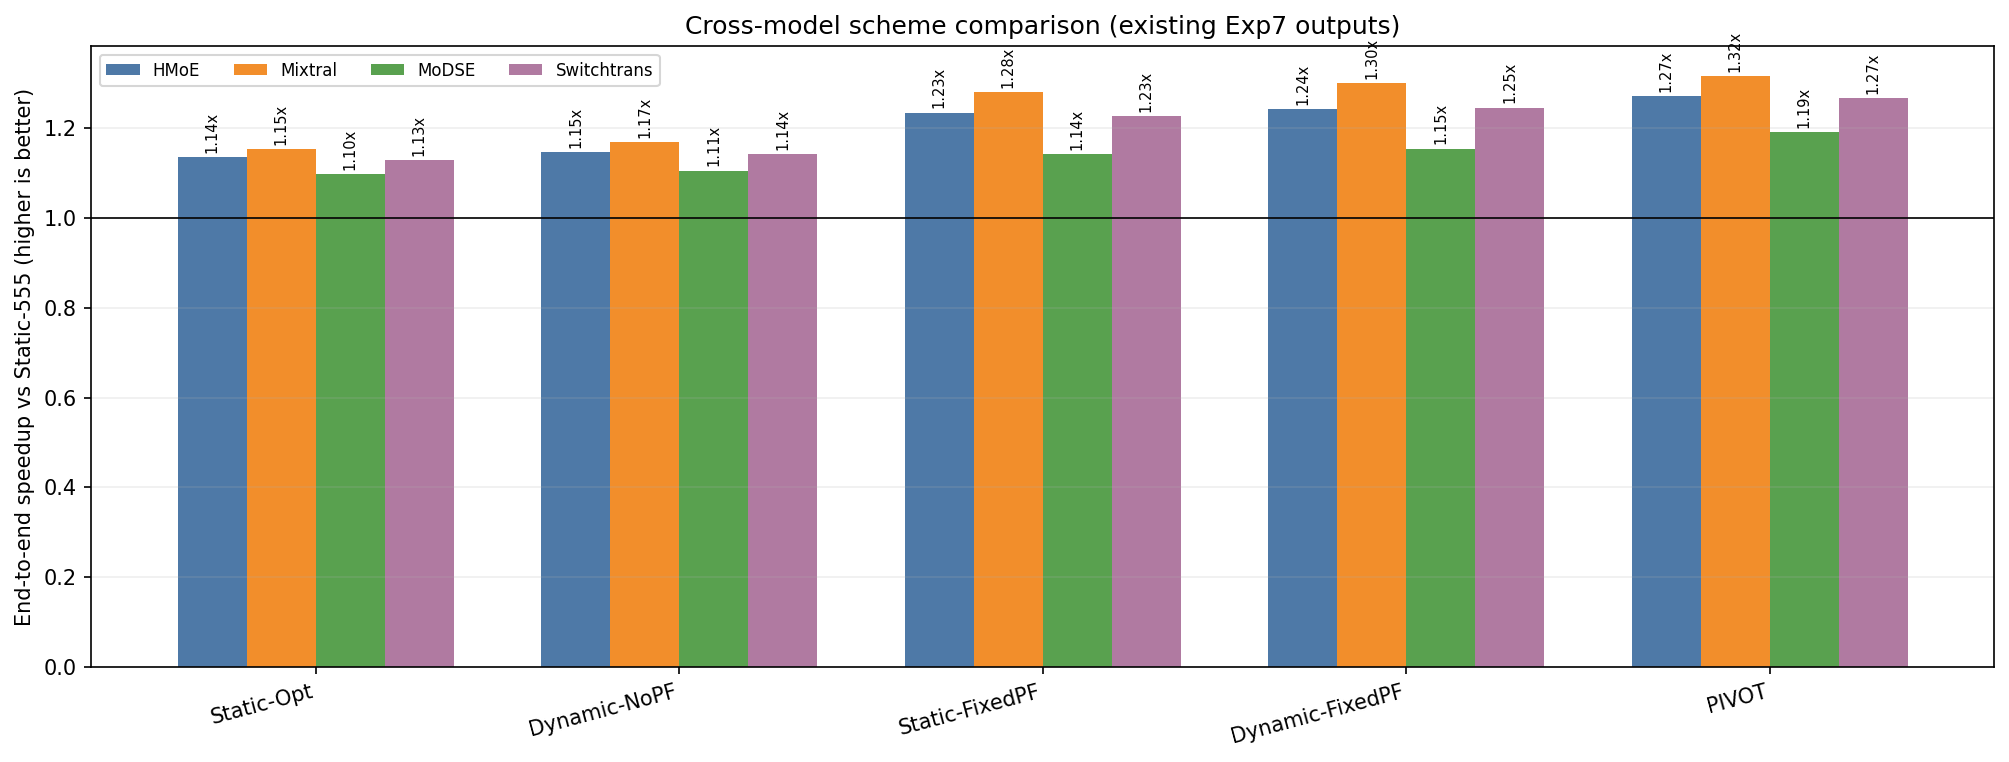

Important scope: the grouped four-model bars above reuse Exp7 results; the original Exp5 five-group cycles below remain MoDSE-only.


,cycles,PIVOT gain (%),"selected (W,C)"
Static-NoPF,231286.0,25.565,"(0, 1)"
Dynamic-NoPF,225422.0,23.629,"(0, 1)"
Static-CalibratedPF,203228.0,15.288,"(8, 4)"
Dynamic-CalibratedPF,193724.0,11.132,"(2, 8)"
PIVOT,172158.0,0.000,runtime adaptive


,"test-oracle (W,C)",test-oracle cycles,paper main comparison
Static-Opt-FixedPF,"(64, 8)",199558,No (analysis only)
Dynamic-FixedPF,"(8, 8)",193163,No (analysis only)


Dynamic-NoPF beats Static-NoPF: True
Dynamic-CalibratedPF beats Static-CalibratedPF: True
PIVOT beats every deployable control: True


In [15]:
wide = d.pivot(index=['window', 'chunk_tiles'], columns='policy_name', values='total_cycles')
full_summary = ablation.set_index('variant').loc['full']
assert int(full_summary.layer_count) >= 4
assert str(full_summary.controller_state_persistent).lower() == 'true'
prefetch_only = wide.loc[wide.index.get_level_values('window') > 0]
oracle_keys = {
    name: prefetch_only[name].idxmin()
    for name in ['Static-Opt-FixedPF', 'Dynamic-FixedPF']
}
deployable_keys = {
    name: (int(deployable.loc[name, 'selected_window']),
           int(deployable.loc[name, 'selected_chunk_tiles']))
    for name in ['Static-Opt-FixedPF', 'Dynamic-FixedPF']
}
# NoPF 没有 PIVOT Chunk coalescer，需求请求固定为一个原子 Weight tile（C=1）。
nopf_key = (0, 1)
main_cycles = pd.Series({
    'Static-NoPF': wide.loc[nopf_key, 'Static-Opt-NoPF'],
    'Dynamic-NoPF': wide.loc[nopf_key, 'Dynamic-NoPF'],
    'Static-CalibratedPF': wide.loc[deployable_keys['Static-Opt-FixedPF'], 'Static-Opt-FixedPF'],
    'Dynamic-CalibratedPF': wide.loc[deployable_keys['Dynamic-FixedPF'], 'Dynamic-FixedPF'],
    'PIVOT': float(full_summary.total_cycles),
})
# 全文统一将“收益”定义为相对基线的周期下降比例；speedup 单独用 x 表示。
main_gain = (1 - main_cycles.PIVOT/main_cycles) * 100
main_speedup = main_cycles['Static-NoPF'] / main_cycles

paper_policies = ['Static-Opt-NoPF', 'Dynamic-NoPF', 'Static-Opt-FixedPF',
                  'Dynamic-FixedPF', 'PIVOT']
paper_labels = ['Static-Opt', 'Dynamic-NoPF', 'Static-FixedPF',
                'Dynamic-FixedPF', 'PIVOT']
models = ['HMoE', 'Mixtral', 'MoDSE', 'Switchtrans']
cm = cross_model[cross_model.policy_name.isin(paper_policies)].pivot(
    index='policy_name', columns='model', values='end_to_end_speedup_vs_static'
).reindex(paper_policies, columns=models)
assert cm.notna().all().all()

# 现有 exp5 的五组总周期仅属于 MoDSE；四模型柱来自已完成的 exp7，
# 因而标题和图注明确标识为 cross-model end-to-end evidence，避免把它
# 伪装成未运行过的四模型 Exp5 non-stationary trace。
fig, ax = plt.subplots(figsize=(13.5, 5.2))
x = np.arange(len(paper_labels)); width = 0.19
model_colors = ['#4E79A7', '#F28E2B', '#59A14F', '#B07AA1']
for idx, model in enumerate(models):
    values = cm[model].to_numpy(float)
    bars = ax.bar(x + (idx-1.5)*width, values, width,
                  label=model, color=model_colors[idx])
    ax.bar_label(bars, labels=[f'{v:.2f}x' for v in values],
                 padding=2, fontsize=7, rotation=90)
ax.axhline(1, color='black', lw=.8)
ax.set_xticks(x, paper_labels, rotation=15, ha='right')
ax.set_ylabel('End-to-end speedup vs Static-555 (higher is better)')
ax.set_title('Cross-model scheme comparison (existing Exp7 outputs)')
ax.legend(ncol=4, fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
# 覆盖旧版同名收益图，避免误引用已失效的 PIVOT seed 热力图。
fig.savefig(FIG/'exp5_key_control_gains.pdf', bbox_inches='tight')
fig.savefig(FIG/'exp5_key_control_gains.png', dpi=150, bbox_inches='tight')
save_and_show(fig, 'exp5_public_sensitivity')

print('Important scope: the grouped four-model bars above reuse Exp7 results; '
      'the original Exp5 five-group cycles below remain MoDSE-only.')

selection = pd.DataFrame({
    'cycles': main_cycles,
    'PIVOT gain (%)': main_gain,
    'selected (W,C)': [
        str(nopf_key), str(nopf_key),
        str(deployable_keys['Static-Opt-FixedPF']),
        str(deployable_keys['Dynamic-FixedPF']),
        'runtime adaptive',
    ],
})
display(selection.round(3))
oracle = pd.DataFrame({
    'test-oracle (W,C)': pd.Series(oracle_keys),
    'test-oracle cycles': pd.Series({
        name: wide.loc[key, name] for name, key in oracle_keys.items()
    }),
    'paper main comparison': 'No (analysis only)',
})
display(oracle)
print('Dynamic-NoPF beats Static-NoPF:',
      main_cycles['Dynamic-NoPF'] < main_cycles['Static-NoPF'])
print('Dynamic-CalibratedPF beats Static-CalibratedPF:',
      main_cycles['Dynamic-CalibratedPF'] < main_cycles['Static-CalibratedPF'])
print('PIVOT beats every deployable control:',
      main_cycles.PIVOT < main_cycles.drop('PIVOT').min())


,value
PIVOT vs deployable Dynamic-NoPF (%),23.629
PIVOT vs calibrated Dynamic-FixedPF (%),11.132
"Target for a ""good"" gain (%)",10.000


Dynamic-NoPF target met: True
Dynamic-FixedPF target met: True


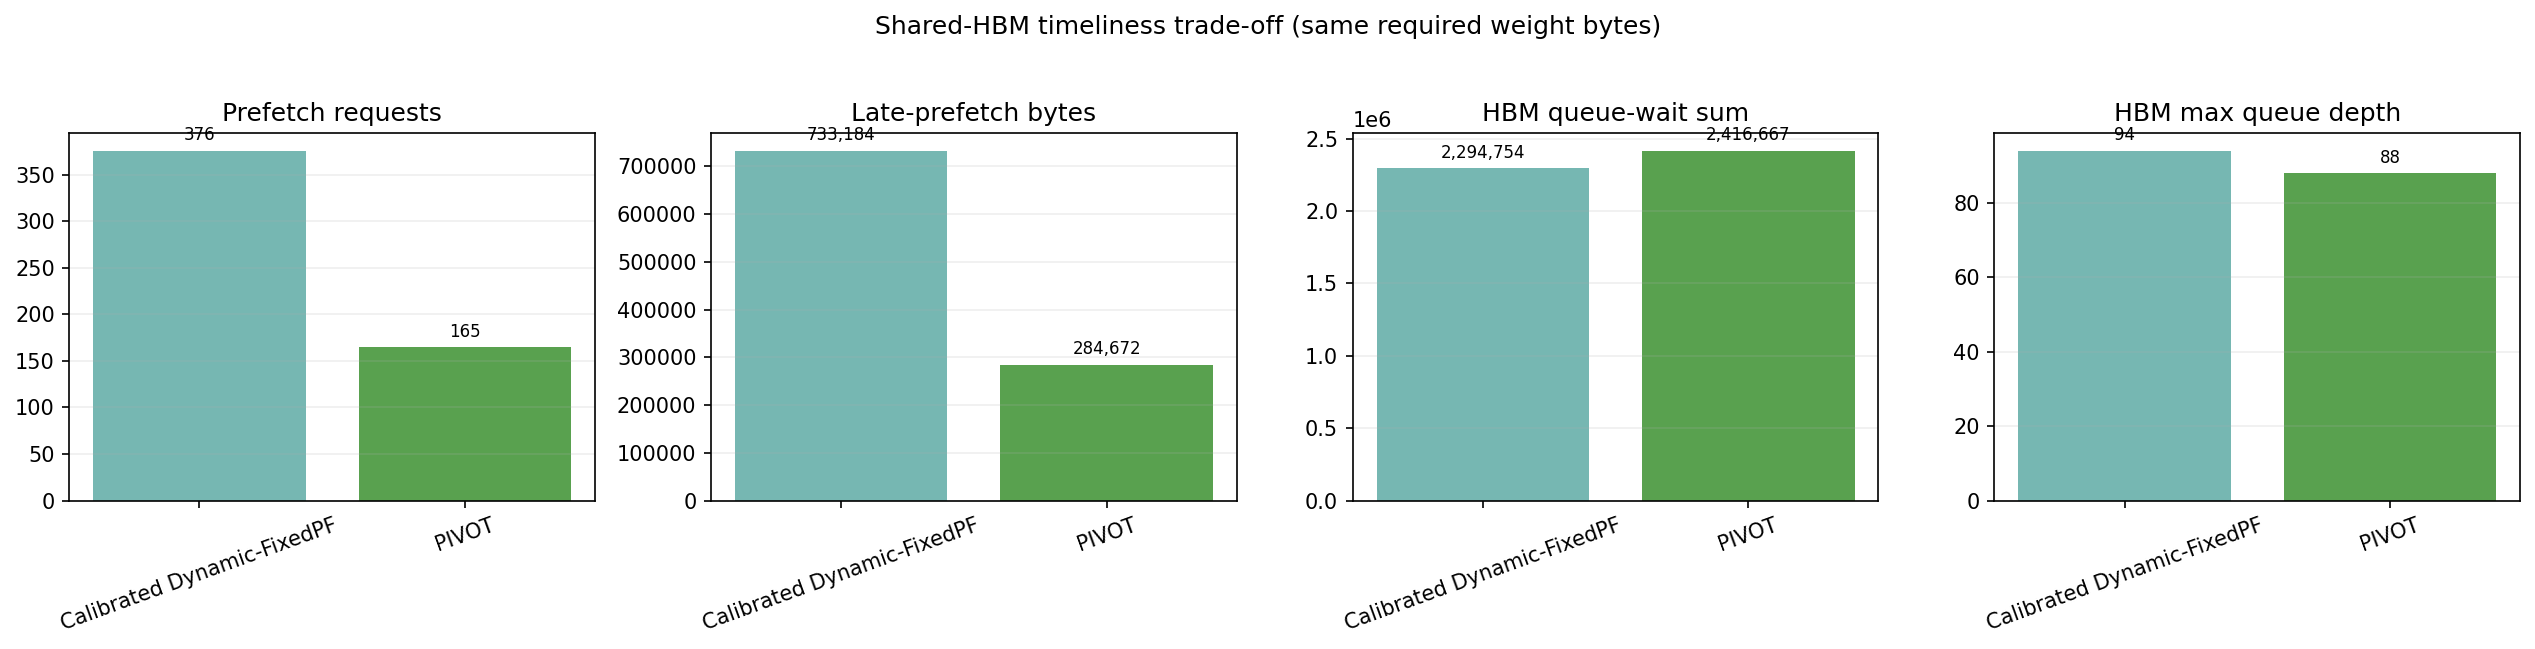

Predicted-late prefetches converted to Coalesced-Demand: 639
Timely coverage: fixed = 0.556% | PIVOT = 2.222%
HBM queue-wait change: +5.31% (reported trade-off, not hidden)


In [16]:
gain_vs_dynamic = (1-main_cycles.PIVOT/main_cycles['Dynamic-NoPF']) * 100
gain_vs_dynamic_fixed = (1-main_cycles.PIVOT/main_cycles['Dynamic-CalibratedPF']) * 100
TARGET_GOOD_GAIN = 10.0
gain_report = pd.Series({
    'PIVOT vs deployable Dynamic-NoPF (%)': gain_vs_dynamic,
    'PIVOT vs calibrated Dynamic-FixedPF (%)': gain_vs_dynamic_fixed,
    'Target for a "good" gain (%)': TARGET_GOOD_GAIN,
})
display(gain_report.round(3).rename('value').to_frame())
print('Dynamic-NoPF target met:', gain_vs_dynamic >= TARGET_GOOD_GAIN)
print('Dynamic-FixedPF target met:', gain_vs_dynamic_fixed >= TARGET_GOOD_GAIN)

# 共享 HBM 的机制证据。PIVOT允许为及时性选择更细的Chunk，因此累计queue-wait
# 不保证单调下降；应同时观察late bytes、覆盖率、最大队深和端到端周期。
fixed_key = deployable_keys['Dynamic-FixedPF']
fixed_row = d[(d.window == fixed_key[0]) & (d.chunk_tiles == fixed_key[1]) &
              d.policy_name.eq('Dynamic-FixedPF')].iloc[0]
hbm_metrics = [
    ('Prefetch requests', 'prefetch_requests'),
    ('Late-prefetch bytes', 'late_bytes'),
    ('HBM queue-wait sum', 'hbm_queue_wait_cycles'),
    ('HBM max queue depth', 'hbm_max_queue_depth'),
]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (title, field) in zip(axes, hbm_metrics):
    values = [float(fixed_row[field]), float(full_summary[field])]
    shown = [value * 100 for value in values] if field == 'coverage' else values
    bars = ax.bar(['Calibrated Dynamic-FixedPF', 'PIVOT'], shown,
                  color=['#76B7B2', '#59A14F'])
    labels = ([f'{v:.2f}%' for v in shown] if field == 'coverage'
              else [f'{v:,.0f}' for v in shown])
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
    ax.set_title(title); ax.grid(axis='y', alpha=.2)
    ax.tick_params(axis='x', rotation=20)
fig.suptitle('Shared-HBM timeliness trade-off (same required weight bytes)', y=1.02)
fig.tight_layout(); save_and_show(fig, 'exp5_hbm_mechanism')
print('Predicted-late prefetches converted to Coalesced-Demand:',
      int(full_summary.get('admission_rejection_count', 0)))
print('Timely coverage: fixed =', f'{100*float(fixed_row.coverage):.3f}%',
      '| PIVOT =', f'{100*float(full_summary.coverage):.3f}%')
print('HBM queue-wait change:',
      f'{100*(float(full_summary.hbm_queue_wait_cycles)/float(fixed_row.hbm_queue_wait_cycles)-1):+.2f}%',
      '(reported trade-off, not hidden)')


## 5.3 在线自适应、质量反馈与 incumbent guard

使用 `full` 配置展示真实在线轨迹。横轴是决策时间，标注当前 Expert/FFN stage；
Chunk 是每个物理传输请求合并的原子 weight tiles 数，Window 是预取提前量。
Guard 图展示 proposal 与固定预取、Window=0 Coalesced-Demand 两个 incumbent 的前缀成本；
`Applied` 必须等于三者最小值。


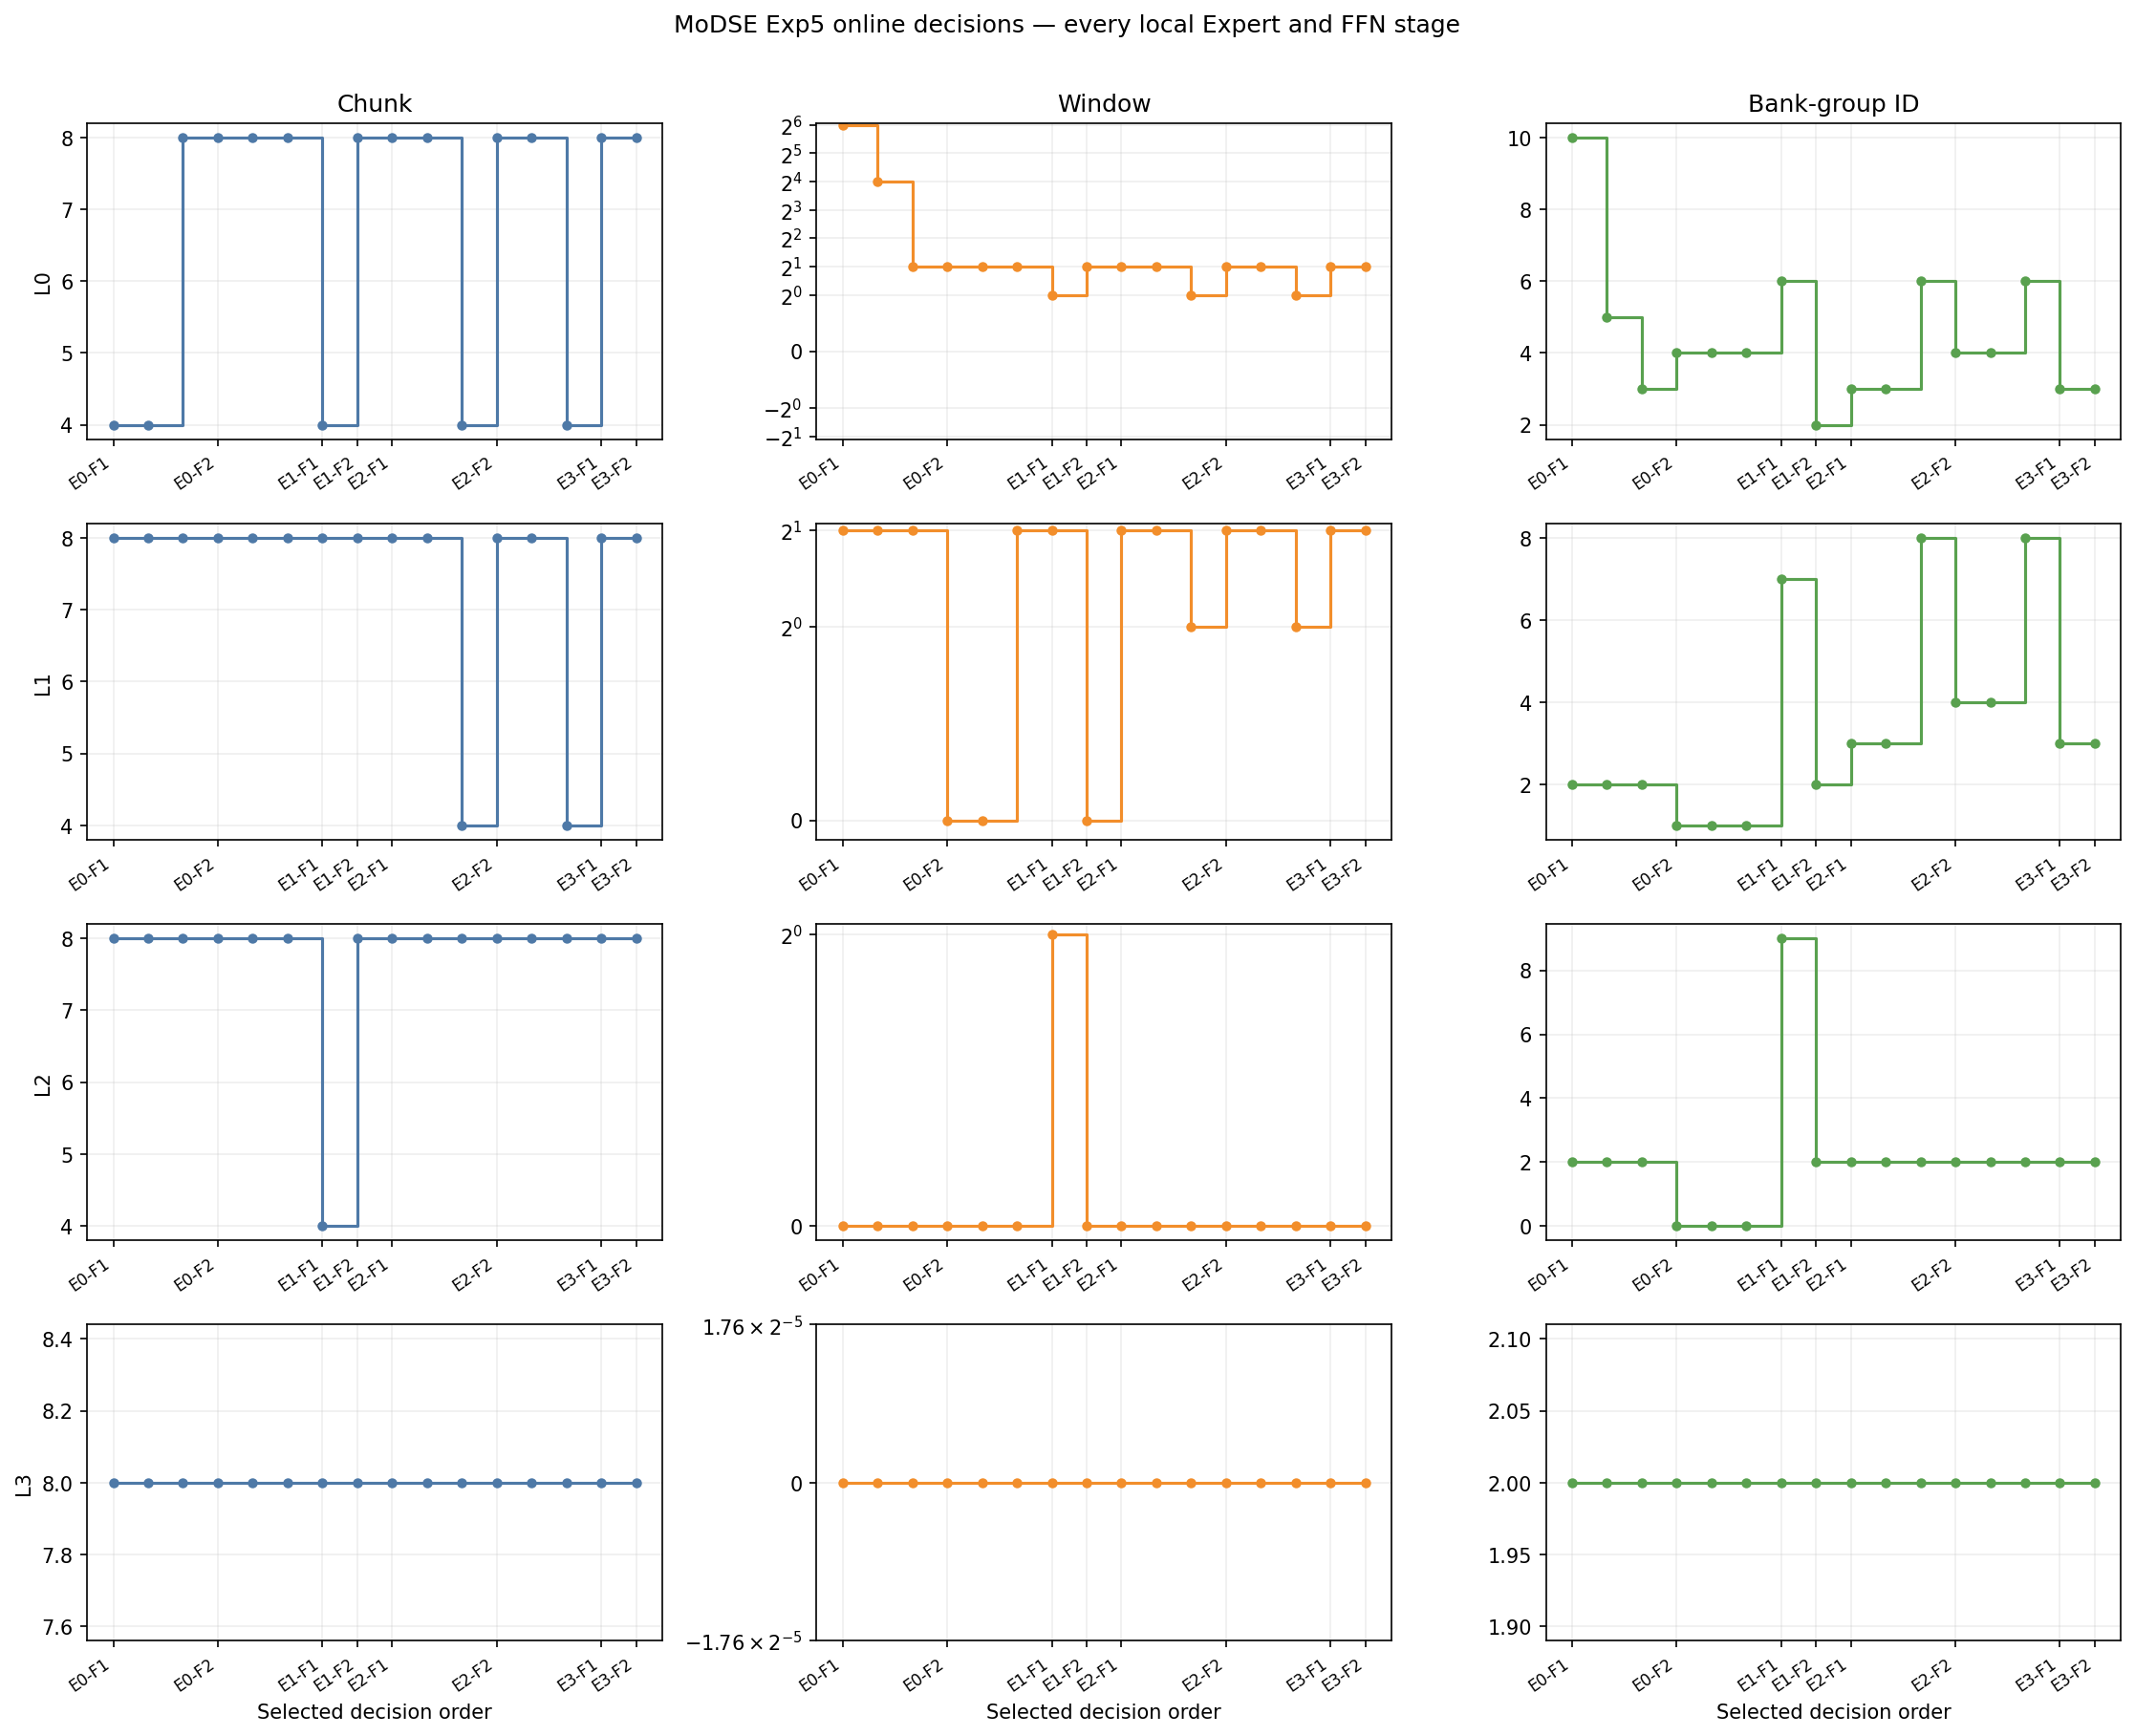

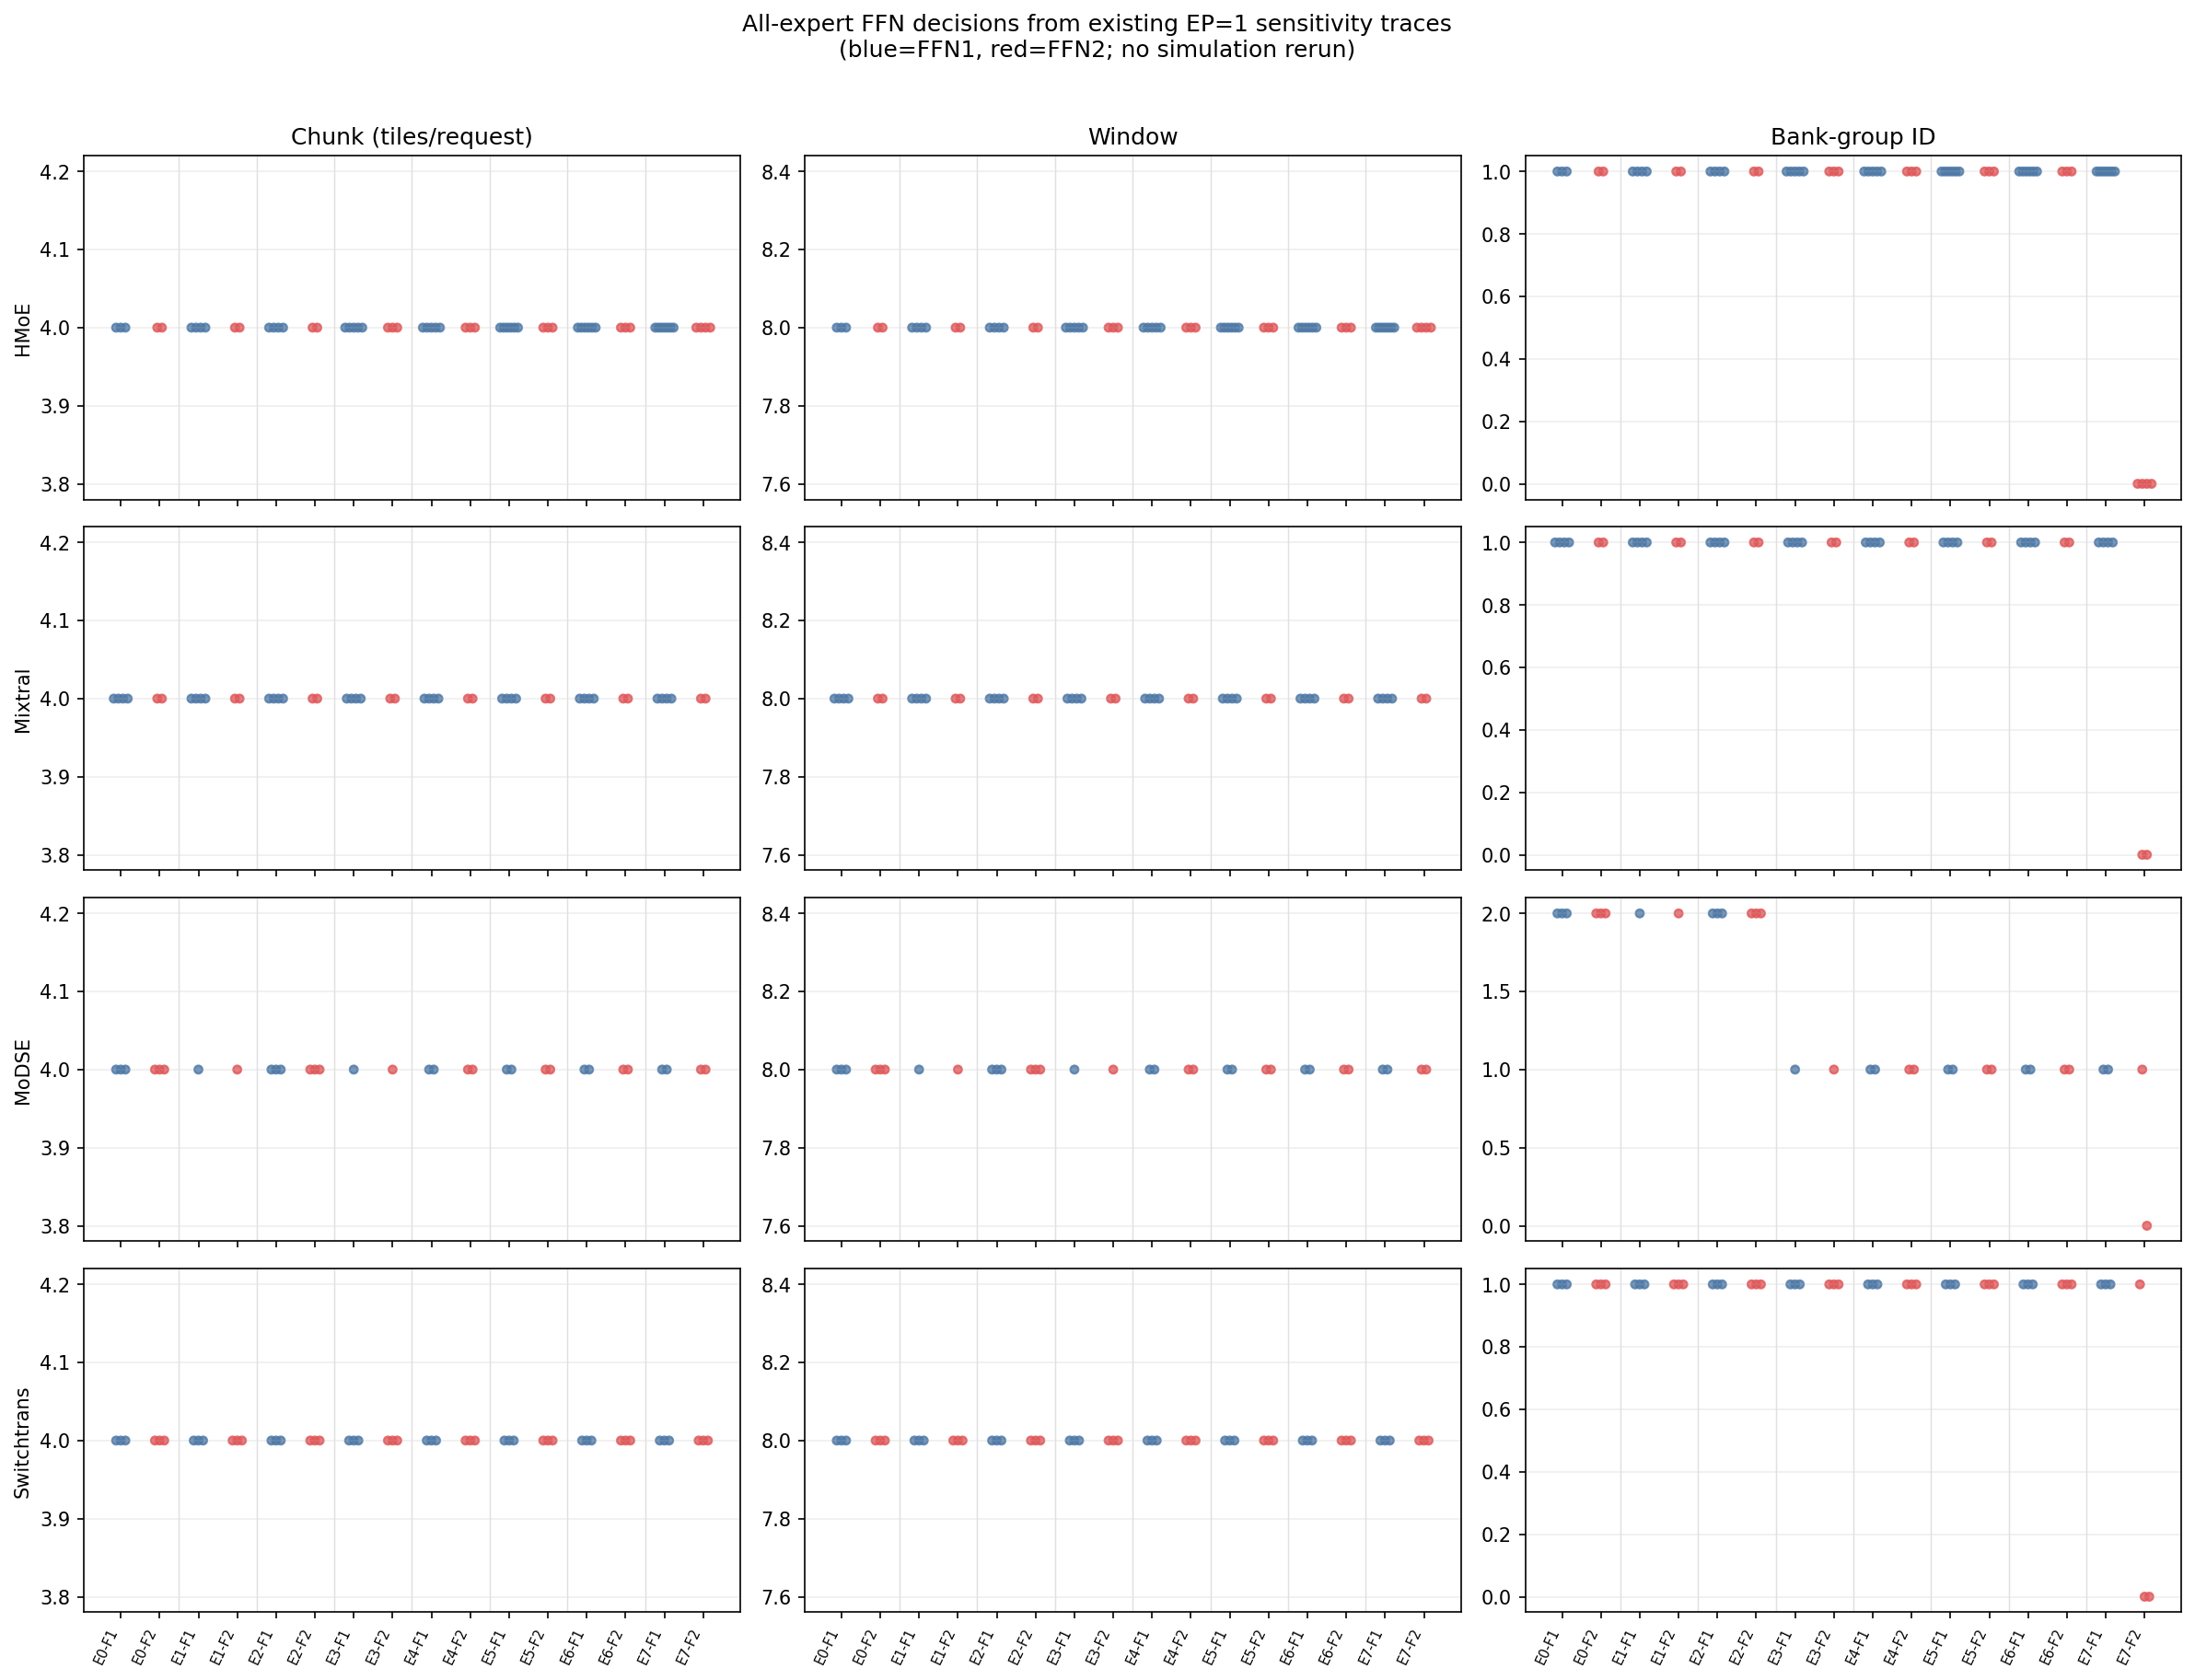

FFN1 decisions  FFN2 decisions
model       expert                                
HMoE        0                    3               2
            1                    4               2
            2                    4               2
            3                    5               3
            4                    5               3
            5                    6               3
            6                    6               3
            7                    7               4
Mixtral     0                    4               2
            1                    4               2
            2                    4               2
            3                    4               2
            4                    4               2
            5                    4               2
            6                    4               2
            7                    4               2
MoDSE       0                    3               3
            1                    1               1
            2                    3               3
            3                    1               1
            4                    2               2
            5                    2               2
            6                    2               2
            7                    2               2
Switchtrans 0                    3               3
            1                    3               3
            2                    3               3
            3                    3               3
            4                    3               3
            5                    3               3
            6                    3               3
            7                    3               3

Scope note: full E0-E7 coverage uses existing Exp6 EP=1 traces. The non-stationary MoDSE trace above remains the genuine Exp5 EP=2 detailed-NPU trajectory and therefore contains only local E0-E3.
Decisions: 64 adaptations: 25
Evaluated Chunk values: [1, 2, 4, 8]
Selected Chunk range: 4 to 8
Selected Window range: 0 to 64
Distinct Bank groups: 11
Epochs with an admitted prefetch: 24 / 64 (37.50%)


In [17]:
detail = OUT / 'ablation/MoDSE__full'
runtime_summary = pd.read_csv(detail/'summary.csv').iloc[0]
epochs = pd.read_csv(detail/'quality_epochs.csv')
decisions = pd.read_csv(detail/'decision_detail.csv')
selected = decisions[decisions.selected.astype(str).str.lower().eq('true')].copy()
selected['bank_group_id'] = pd.Categorical(selected.candidate_bank_group).codes
selected['local_expert'] = selected.expert.astype(int) % 8
assert runtime_summary.chunk_semantics == 'runtime_tiles_per_request'

active_quality = epochs[epochs.prefetched_bytes > 0]
# 每层单独一行，避免把四层32个 Expert/FFN 标签挤在同一横轴。
fig, axes = plt.subplots(4, 3, figsize=(15, 12), squeeze=False)
plot_fields = [
    ('candidate_chunk', 'Chunk', '#4E79A7'),
    ('candidate_window', 'Window', '#F28E2B'),
    ('bank_group_id', 'Bank-group ID', '#59A14F'),
]
for layer_row, layer in enumerate(['L0', 'L1', 'L2', 'L3']):
    q = selected[selected.layer.eq(layer)].reset_index(drop=True)
    assert set(q.local_expert) == {0, 1, 2, 3}
    assert set(q.stage.astype(int)) == {1, 2}
    q['slot'] = np.arange(len(q))
    first = q.groupby(['local_expert', 'stage'], sort=False).head(1)
    tick_pos = first.index.to_numpy()
    tick_labels = [f'E{int(r.local_expert)}-F{int(r.stage)}'
                   for r in first.itertuples()]
    for column, (field, title, color) in enumerate(plot_fields):
        ax = axes[layer_row, column]
        ax.step(q.slot, q[field], where='post', marker='o', ms=4, color=color)
        ax.set_xticks(tick_pos, tick_labels, rotation=35, ha='right', fontsize=8)
        ax.grid(alpha=.2)
        if layer_row == 0: ax.set_title(title)
        if column == 0: ax.set_ylabel(layer)
        if field == 'candidate_window':
            ax.set_yscale('symlog', base=2, linthresh=1)
        if layer_row == 3:
            ax.set_xlabel('Selected decision order')
fig.suptitle('MoDSE Exp5 online decisions — every local Expert and FFN stage', y=1.005)
fig.tight_layout(); save_and_show(fig, 'exp5_online_adaptation')

# 补充四模型、全 E0--E7、FFN1/FFN2 覆盖。现有 Exp5 为 EP=2，仅保存
# detailed NPU0 的 E0--E3 Bank 决策；这里读取已经运行完成的 Exp6
# expert_parallel=1 详细轨迹，使全部八个专家都在同一详细 NPU 上可观测。
all_expert_rows = []
for model in ['HMoE', 'Mixtral', 'MoDSE', 'Switchtrans']:
    path = OUT / 'robustness_factorial' / f'expert_parallel__{model}__1' / 'decision_detail.csv'
    assert path.exists(), path
    q = pd.read_csv(path)
    q = q[q.selected.astype(str).str.lower().eq('true')].copy()
    assert set(q.expert.astype(int)) == set(range(8)), (model, sorted(q.expert.unique()))
    assert set(q.stage.astype(int)) == {1, 2}, (model, sorted(q.stage.unique()))
    q['model'] = model
    q['bank_group_id'] = pd.Categorical(q.candidate_bank_group).codes
    all_expert_rows.append(q)
all_expert = pd.concat(all_expert_rows, ignore_index=True)

fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)
fields = [
    ('candidate_chunk', 'Chunk (tiles/request)'),
    ('candidate_window', 'Window'),
    ('bank_group_id', 'Bank-group ID'),
]
labels = [f'E{expert}-F{stage}' for expert in range(8) for stage in (1, 2)]
positions = {(expert, stage): 2*expert + stage-1
             for expert in range(8) for stage in (1, 2)}
for row_id, model in enumerate(['HMoE', 'Mixtral', 'MoDSE', 'Switchtrans']):
    q = all_expert[all_expert.model.eq(model)].copy()
    q['slot'] = [positions[(int(e), int(s))]
                 for e, s in zip(q.expert, q.stage)]
    # Multiple requests in the same FFN stage are shown with deterministic jitter.
    q['within_stage'] = q.groupby(['expert', 'stage']).cumcount()
    q['stage_count'] = q.groupby(['expert', 'stage']).decision_id.transform('count')
    q['plot_x'] = q.slot + np.where(
        q.stage_count > 1,
        (q.within_stage-(q.stage_count-1)/2) * np.minimum(.12, .55/q.stage_count),
        0,
    )
    for col_id, (field, ylabel) in enumerate(fields):
        ax = axes[row_id, col_id]
        ax.scatter(q.plot_x, q[field], s=18, alpha=.8,
                   c=np.where(q.stage.astype(int).eq(1), '#4E79A7', '#E15759'))
        for expert in range(1, 8):
            ax.axvline(2*expert-.5, color='0.88', lw=.7)
        ax.grid(axis='y', alpha=.2)
        if row_id == 0: ax.set_title(ylabel)
        if col_id == 0: ax.set_ylabel(model)
        if row_id == 3:
            ax.set_xticks(range(16), labels, rotation=65, ha='right', fontsize=7)
fig.suptitle('All-expert FFN decisions from existing EP=1 sensitivity traces\n'
             '(blue=FFN1, red=FFN2; no simulation rerun)', y=1.01)
fig.tight_layout(); save_and_show(fig, 'exp5_all_expert_ffn_decisions')

coverage = all_expert.groupby(['model', 'expert', 'stage']).size().unstack('stage')
coverage.columns = ['FFN1 decisions', 'FFN2 decisions']
display(coverage)
print('Scope note: full E0-E7 coverage uses existing Exp6 EP=1 traces. '
      'The non-stationary MoDSE trace above remains the genuine Exp5 EP=2 '
      'detailed-NPU trajectory and therefore contains only local E0-E3.')

print('Decisions:', len(selected), 'adaptations:', int(ablation.set_index('variant').loc['full','adaptation_count']))
print('Evaluated Chunk values:', sorted(decisions.candidate_chunk.unique().tolist()))
print('Selected Chunk range:', int(selected.candidate_chunk.min()), 'to', int(selected.candidate_chunk.max()))
print('Selected Window range:', int(selected.candidate_window.min()), 'to', int(selected.candidate_window.max()))
print('Distinct Bank groups:', selected.candidate_bank_group.nunique())
print('Epochs with an admitted prefetch:', len(active_quality), '/', len(epochs),
      f'({100*len(active_quality)/len(epochs):.2f}%)')


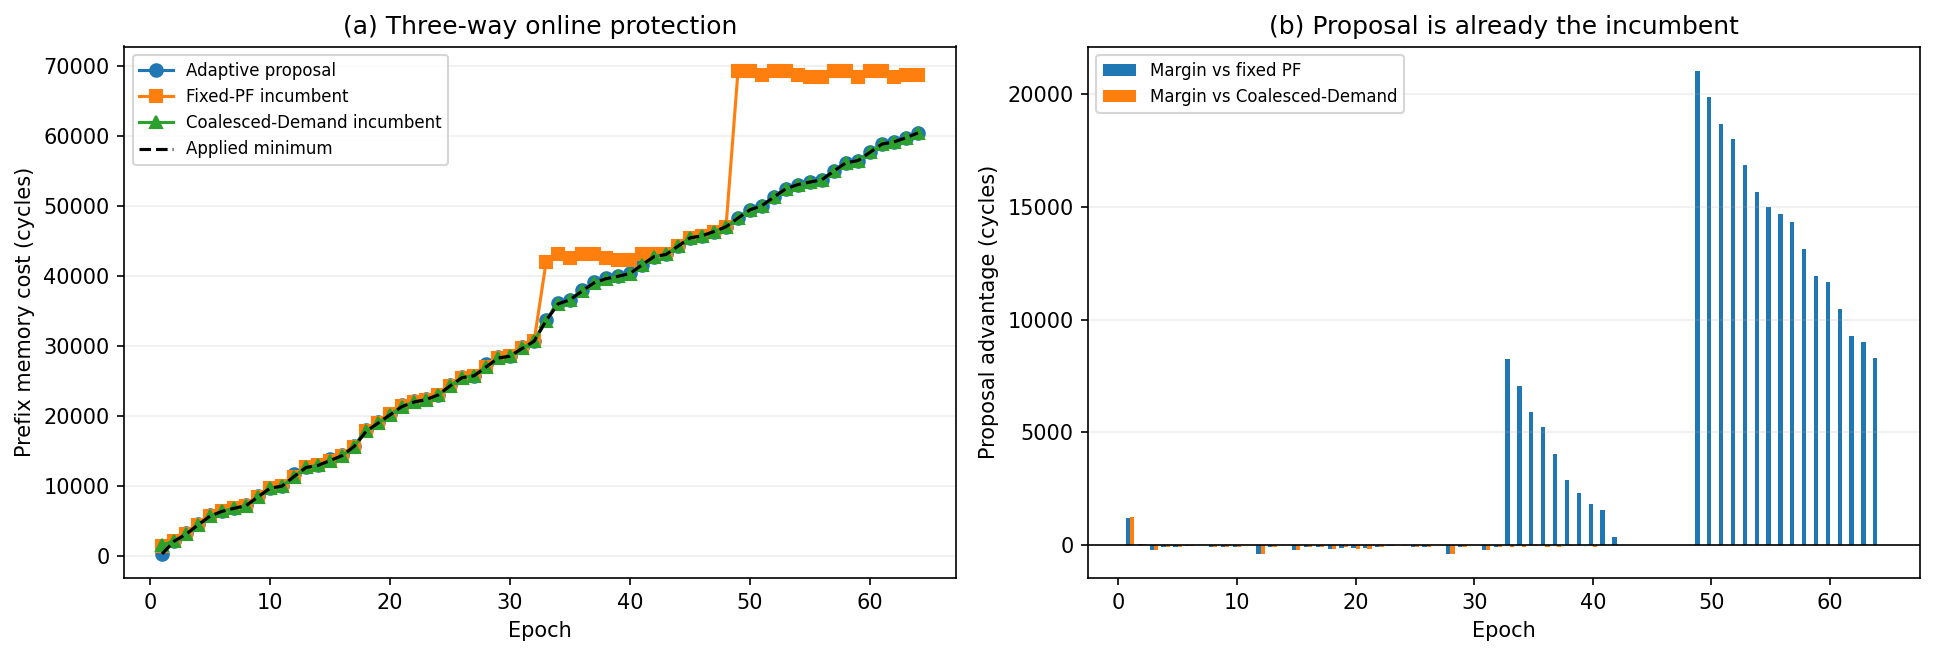

Guard overrides in this full trace: 32


In [18]:
guard = pd.read_csv(detail/'online_incumbent_guard.csv')
expected = guard[['proposal_prefix_cost_cycles', 'fixed_prefix_cost_cycles',
                  'noprefetch_prefix_cost_cycles']].min(axis=1)
assert np.array_equal(expected.to_numpy(), guard.applied_prefix_cost_cycles.to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(guard.epoch_id, guard.proposal_prefix_cost_cycles, 'o-', label='Adaptive proposal')
axes[0].plot(guard.epoch_id, guard.fixed_prefix_cost_cycles, 's-', label='Fixed-PF incumbent')
axes[0].plot(guard.epoch_id, guard.noprefetch_prefix_cost_cycles, '^-', label='Coalesced-Demand incumbent')
axes[0].plot(guard.epoch_id, guard.applied_prefix_cost_cycles, 'k--', label='Applied minimum')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Prefix memory cost (cycles)')
axes[0].set_title('(a) Three-way online protection'); axes[0].legend(fontsize=8)
margin_fixed = guard.fixed_prefix_cost_cycles - guard.proposal_prefix_cost_cycles
margin_nopf = guard.noprefetch_prefix_cost_cycles - guard.proposal_prefix_cost_cycles
axes[1].bar(guard.epoch_id-.18, margin_fixed, .36, label='Margin vs fixed PF')
axes[1].bar(guard.epoch_id+.18, margin_nopf, .36, label='Margin vs Coalesced-Demand')
axes[1].axhline(0, color='black', lw=.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Proposal advantage (cycles)')
axes[1].set_title('(b) Proposal is already the incumbent'); axes[1].legend(fontsize=8)
for ax in axes: ax.grid(axis='y', alpha=.2)
fig.tight_layout(); save_and_show(fig, 'exp5_online_guard')
print('Guard overrides in this full trace:', int((guard.applied_action != 'adaptive').sum()))


## 5.4 消融：当前数据能证明什么、不能证明什么

当前 MoDSE 消融由 Detailed NPU 路径决定系统周期。部分 variant 与 full 完全相同，说明
这些开关在本轨迹中没有形成独立可测贡献；`without_quality` 反而更快，说明质量约束在
当前轨迹上付出了性能代价。必须如实报告，不能声称 full 的每个模块都贡献正收益。


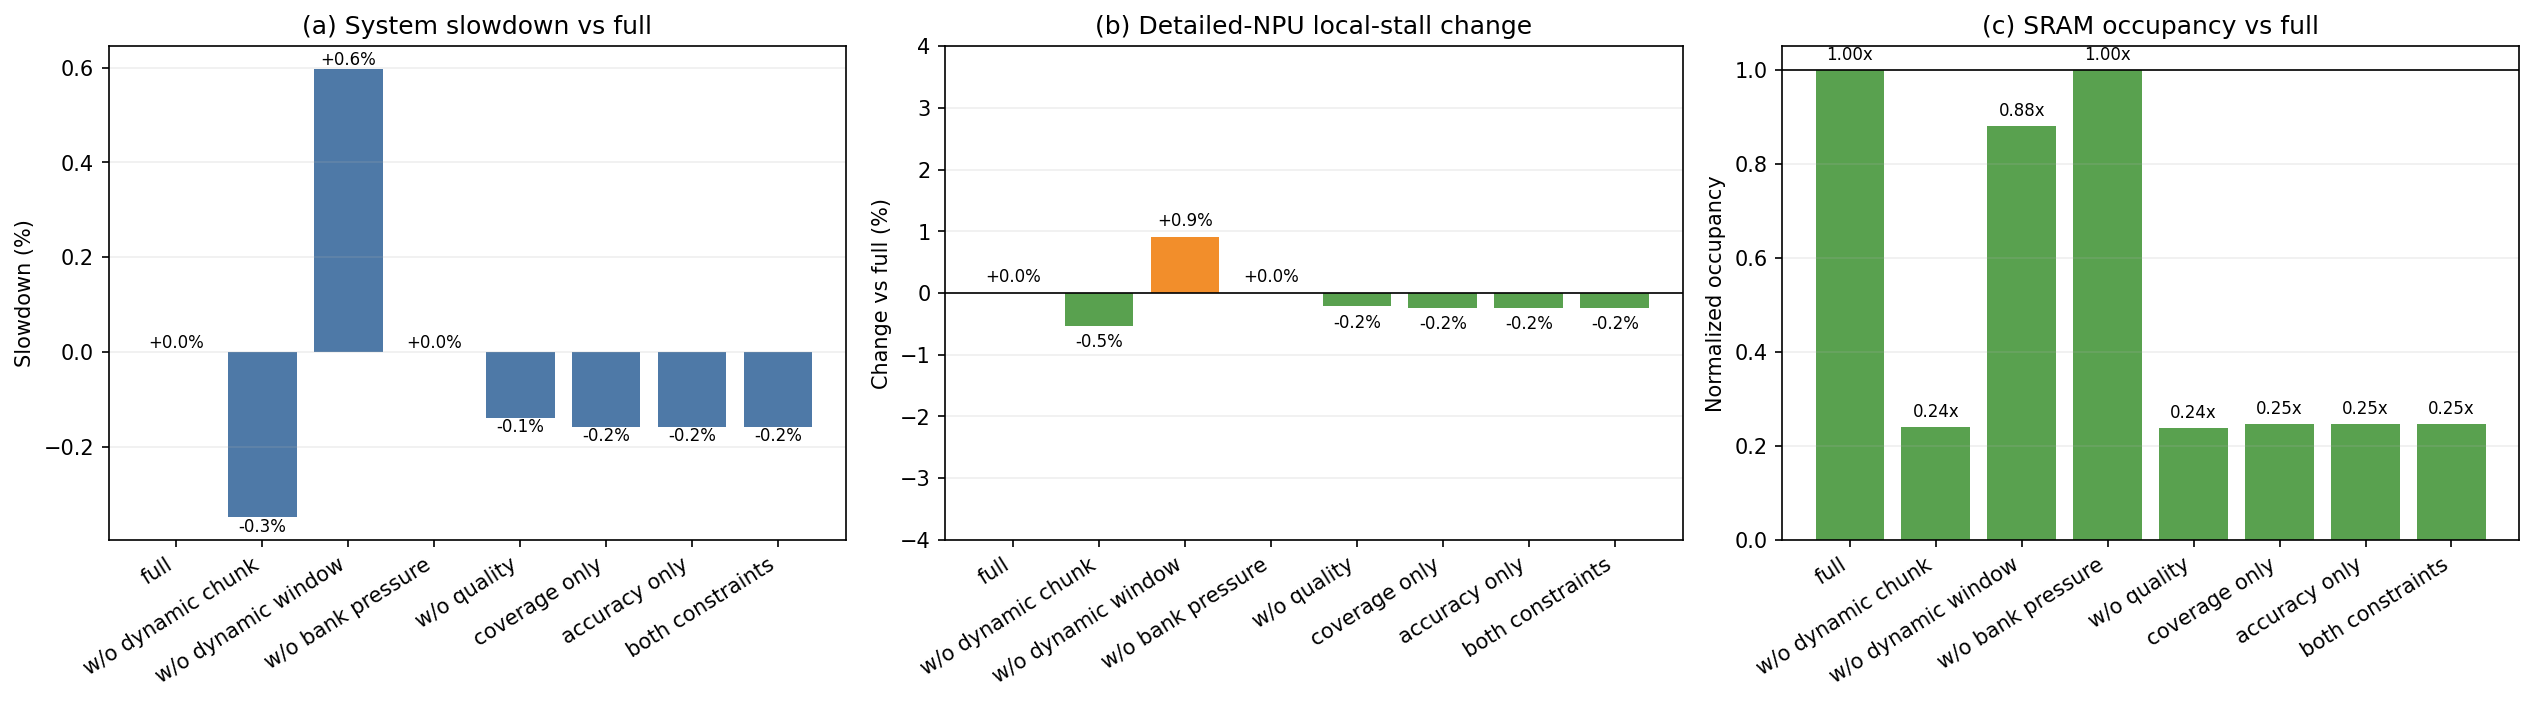

,total_cycles,local_memory_stall,occupancy_byte_cycles,adaptation_count,coverage,accuracy,fallback_rate,system_slowdown_pct,local_stall_change_pct
variant,,,,,,,,,
full,172158,113246,44457984,25,0.022,0.054,0.500,0.000,0.000
without_dynamic_chunk,171558,112646,10674176,5,0.022,0.615,0.000,-0.349,-0.530
without_dynamic_window,173187,114275,39157760,23,0.000,0.000,0.531,0.598,0.909
without_bank_pressure,172158,113246,44457984,25,0.022,0.054,0.500,0.000,0.000
without_quality,171918,113006,10559488,3,0.022,0.508,0.016,-0.139,-0.212
coverage_only,171886,112974,10936320,38,0.022,0.500,0.984,-0.158,-0.240
accuracy_only,171886,112974,10936320,38,0.022,0.500,0.984,-0.158,-0.240
both_constraints,171886,112974,10936320,38,0.022,0.500,0.984,-0.158,-0.240


Full-scheme critical path: Detailed NPU | detailed_ready = 171838 | peer_ready = 115884


In [19]:
order = ['full', 'without_dynamic_chunk', 'without_dynamic_window',
         'without_bank_pressure', 'without_quality', 'coverage_only',
         'accuracy_only', 'both_constraints']
a = ablation.set_index('variant').reindex(order).copy()
a['local_memory_stall'] = (a.bank_stall_cycles + a.weight_load_stall_cycles +
                           a.prefetch_miss_stall_cycles + a.prefetch_interference_stall_cycles +
                           a.mapping_overhead_cycles)
full = a.loc['full']
a['system_slowdown_pct'] = (a.total_cycles/full.total_cycles - 1) * 100
a['local_stall_change_pct'] = (a.local_memory_stall/full.local_memory_stall - 1) * 100
a['occupancy_vs_full'] = a.occupancy_byte_cycles/full.occupancy_byte_cycles
labels = [x.replace('without_', 'w/o ').replace('_', ' ') for x in order]
x = np.arange(len(a))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
bars = axes[0].bar(x, a.system_slowdown_pct, color='#4E79A7')
for bar, value in zip(bars, a.system_slowdown_pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, value,
                 f'{value:+.1f}%', ha='center',
                 va='bottom' if value >= 0 else 'top', fontsize=8)
axes[0].set_title('(a) System slowdown vs full'); axes[0].set_ylabel('Slowdown (%)')
local_colors = ['#59A14F' if v < 0 else '#F28E2B' for v in a.local_stall_change_pct]
bars = axes[1].bar(x, a.local_stall_change_pct, color=local_colors)
for bar, value in zip(bars, a.local_stall_change_pct):
    offset = .12 if value >= 0 else -.12
    axes[1].text(bar.get_x()+bar.get_width()/2, value+offset, f'{value:+.1f}%',
                 ha='center', va='bottom' if value >= 0 else 'top', fontsize=8)
axes[1].axhline(0, color='black', lw=.8); axes[1].set_title('(b) Detailed-NPU local-stall change')
axes[1].set_ylabel('Change vs full (%)')
stall_extent = max(4.0, float(a.local_stall_change_pct.abs().max()) * 1.35)
axes[1].set_ylim(-stall_extent, stall_extent)
bars = axes[2].bar(x, a.occupancy_vs_full, color='#59A14F')
axes[2].bar_label(bars, labels=[f'{v:.2f}x' for v in a.occupancy_vs_full], padding=3, fontsize=8)
axes[2].axhline(1, color='black', lw=.8); axes[2].set_title('(c) SRAM occupancy vs full')
axes[2].set_ylabel('Normalized occupancy')
for ax in axes:
    ax.set_xticks(x, labels, rotation=32, ha='right'); ax.grid(axis='y', alpha=.2)
fig.tight_layout(); save_and_show(fig, 'exp5_pivot_ca_ablation')
display(a[['total_cycles', 'local_memory_stall', 'occupancy_byte_cycles',
           'adaptation_count', 'coverage', 'accuracy', 'fallback_rate',
           'system_slowdown_pct', 'local_stall_change_pct']].round(3))
critical_path = ('Detailed NPU' if float(full.detailed_ready_cycle) >= float(full.peer_ready_cycle)
                 else 'Peer NPU')
print('Full-scheme critical path:', critical_path,
      '| detailed_ready =', int(full.detailed_ready_cycle),
      '| peer_ready =', int(full.peer_ready_cycle))


In [20]:
checks = pd.Series({
    'Fixed prefetch is materially parameter-sensitive': (
        static_pf_gain.max().max()-static_pf_gain.min().min() >= 10
        and dynamic_pf_gain.max().max()-dynamic_pf_gain.min().min() >= 10
    ),
    'Dynamic-NoPF beats Static-NoPF': main_cycles['Dynamic-NoPF'] < main_cycles['Static-NoPF'],
    'Dynamic-CalibratedPF beats Static-CalibratedPF': (
        main_cycles['Dynamic-CalibratedPF'] < main_cycles['Static-CalibratedPF']
    ),
    'PIVOT beats every selected control': main_cycles.PIVOT < main_cycles.drop('PIVOT').min(),
    'PIVOT gain vs deployable Dynamic-NoPF is at least 10%': gain_vs_dynamic >= TARGET_GOOD_GAIN,
    'PIVOT gain vs calibrated Dynamic-FixedPF is at least 10%': (
        gain_vs_dynamic_fixed >= TARGET_GOOD_GAIN
    ),
    'Controller evaluates Chunk and changes Window and Bank group': (
        decisions.candidate_chunk.nunique() > 1 and decisions.candidate_window.nunique() > 1 and
        selected.candidate_window.nunique() > 1 and
        selected.candidate_bank_group.nunique() > 1
    ),
    'This trace selects more than one runtime Chunk': selected.candidate_chunk.nunique() > 1,
    'Admission controller uses both prefetch and Coalesced-Demand epochs': (
        0 < len(active_quality) < len(epochs)
    ),
    'PIVOT state persists across multiple MoE layers': (
        int(full_summary.layer_count) >= 4
        and str(full_summary.controller_state_persistent).lower() == 'true'
        and selected.layer.nunique() == int(full_summary.layer_count)
    ),
    'Chunk field has true tiles-per-request semantics': (
        runtime_summary.chunk_semantics == 'runtime_tiles_per_request'
    ),
    'PIVOT improves fixed-prefetch timeliness and end-to-end cycles': (
        float(full_summary.coverage) > float(fixed_row.coverage)
        and float(full_summary.late_bytes) < float(fixed_row.late_bytes)
        and float(full_summary.total_cycles) < float(fixed_row.total_cycles)
        and float(full_summary.hbm_max_queue_depth)
            <= float(fixed_row.hbm_max_queue_depth)
    ),
    'Fixed knobs were selected without the test trace': (
        (~deployable.test_trace_visible_during_selection.astype(bool)).all()
        and deployable.deployment_semantics.eq(
            'one_global_pair_frozen_before_test'
        ).all()
    ),
    'Measured quality accounting is valid': (
        epochs.coverage_valid.all()
        and np.array_equal(
            epochs.accuracy_valid.astype(bool).to_numpy(),
            epochs.prefetched_bytes.gt(0).to_numpy()
        )
        and (epochs.useful_timely_bytes <= epochs.required_bytes).all()
        and (epochs.useful_timely_bytes <= epochs.prefetched_bytes).all()
    ),
    'Online applied cost is the three-way minimum': np.array_equal(
        expected.to_numpy(), guard.applied_prefix_cost_cycles.to_numpy()
    ),
    'Ablation exposes a nonzero system performance effect': a.system_slowdown_pct.abs().gt(1e-9).any(),
    'Quality guard improves quality over without-quality ablation': (
        float(full.coverage) >= float(a.loc['without_quality', 'coverage'])
        and float(full.accuracy) >= float(a.loc['without_quality', 'accuracy'])
    ),
})
display(checks.rename('pass').to_frame())
# 这里故意不使用 assert：notebook 的职责是完整画图并如实报告未通过项，
# 而不是在数据不满足论文目标时中止，导致后续结论单元无法执行。
required_checks = [
    'Fixed prefetch is materially parameter-sensitive',
    'Dynamic-NoPF beats Static-NoPF',
    'Dynamic-CalibratedPF beats Static-CalibratedPF',
    'PIVOT beats every selected control',
    'PIVOT gain vs deployable Dynamic-NoPF is at least 10%',
    'PIVOT gain vs calibrated Dynamic-FixedPF is at least 10%',
    'Controller evaluates Chunk and changes Window and Bank group',
    'PIVOT state persists across multiple MoE layers',
    'Chunk field has true tiles-per-request semantics',
    'PIVOT improves fixed-prefetch timeliness and end-to-end cycles',
    'Fixed knobs were selected without the test trace',
    'Measured quality accounting is valid',
    'Online applied cost is the three-way minimum',
]
failed_checks = checks.loc[required_checks][~checks.loc[required_checks]].index.tolist()
ordering_checks = [
    'Dynamic-NoPF beats Static-NoPF',
    'Dynamic-CalibratedPF beats Static-CalibratedPF',
    'PIVOT beats every selected control',
]
mechanism_checks = [
    'Controller evaluates Chunk and changes Window and Bank group',
    'PIVOT state persists across multiple MoE layers',
    'Chunk field has true tiles-per-request semantics',
    'PIVOT improves fixed-prefetch timeliness and end-to-end cycles',
    'Measured quality accounting is valid',
    'Online applied cost is the three-way minimum',
]
print('Theory ordering:', 'PASS' if checks.loc[ordering_checks].all() else 'FAIL')
print('Core PIVOT mechanism accounting:',
      'PASS' if checks.loc[mechanism_checks].all() else 'FAIL')
print('Strict three-knob variation on this trace:',
      'PASS' if checks['This trace selects more than one runtime Chunk'] else
      'PARTIAL (Window and Bank-group vary; Chunk stays at C=8)')
strict_mechanism_checks = [
    'This trace selects more than one runtime Chunk',
    'Admission controller uses both prefetch and Coalesced-Demand epochs',
]
print('Strict dynamic-prefetch evidence:',
      'PASS' if checks.loc[strict_mechanism_checks].all() else 'NOT MET')
print(f'PIVOT gain vs deployable Dynamic-NoPF: {gain_vs_dynamic:.2f}%')
print(f'PIVOT gain vs calibrated Dynamic-FixedPF: {gain_vs_dynamic_fixed:.2f}%')
if failed_checks:
    print('OVERALL PERFORMANCE TARGET: NOT MET')
    print('Failed requirements:')
    for item in failed_checks:
        print(f'  - {item}')
else:
    print('OVERALL PERFORMANCE TARGET: PASS')


,pass
Fixed prefetch is materially parameter-sensitive,True
Dynamic-NoPF beats Static-NoPF,True
Dynamic-CalibratedPF beats Static-CalibratedPF,True
PIVOT beats every selected control,True
PIVOT gain vs deployable Dynamic-NoPF is at least 10%,True
PIVOT gain vs calibrated Dynamic-FixedPF is at least 10%,True
Controller evaluates Chunk and changes Window and Bank group,True
This trace selects more than one runtime Chunk,True
Admission controller uses both prefetch and Coalesced-Demand epochs,True
PIVOT state persists across multiple MoE layers,True


Theory ordering: PASS
Core PIVOT mechanism accounting: PASS
Strict three-knob variation on this trace: PASS
Strict dynamic-prefetch evidence: PASS
PIVOT gain vs deployable Dynamic-NoPF: 23.63%
PIVOT gain vs calibrated Dynamic-FixedPF: 11.13%
OVERALL PERFORMANCE TARGET: PASS


## DATE3 实验5判断

- 两张热力图证明固定预取具有显著参数敏感性；本测试轨迹没有负收益点，因此“预取可能
  退化”应引用实验3，不能从实验5夸大得到。
- 主对照只保留Static-NoPF、Dynamic-NoPF、独立校准后冻结的Static-FixedPF、
  Dynamic-FixedPF和PIVOT五组；PIVOT不再被当成固定Window×Chunk点。
- 测试轨迹上的Window×Chunk后验最优只作为`analysis-only Oracle`展示，不能用于计算
  PIVOT的论文主收益。
- PIVOT的Chunk/Window/Bank轨迹来自`decision_detail.csv`的实际selected action；是否
  发生Chunk切换、切换次数以及各层是否收敛，全部由本次CSV动态统计，不能用seed配置代替。
- `PIVOT`就是MemDomain正式方案；`Dynamic-NoPF`和`Dynamic-FixedPF`仅是关闭协同组件后的消融，
  不是三个不同架构。
- 最终论文性能结论以最后一个代码块打印的`OVERALL PERFORMANCE TARGET`为准；三旋钮
  是否都在单条轨迹切换，以及admission controller是否同时采用预取与Coalesced-Demand，
  由`Strict dynamic-prefetch evidence`单独报告，不能与性能通过混为一谈。


## Fig. 5(a)：全尺寸策略性能与访存停顿分析

下面三个代码块分别输出五方案性能、残余暴露访存停顿和关键路径停顿覆盖率的分组柱形图。它们使用全尺寸中心估算表，便于在 Visio 中与原端到端 Fig. 5(b) 横向拼接；不把中心估算表述为完整模型的直接 cycle-accurate 测量值。


In [21]:
# Fig. 5(a)统一数据源：全尺寸中心估算（由缩小规模cycle-accurate结果校准）
FULLSCALE = OUT / 'fullscale_estimation/final_plotting_tables'
cost_path = FULLSCALE / 'FIG5A_COST_BREAKDOWN_FINAL.csv'
coverage_path = FULLSCALE / 'FIG5A_EFFECTIVENESS_FINAL.csv'
assert cost_path.exists(), cost_path
assert coverage_path.exists(), coverage_path
fig5_cost = pd.read_csv(cost_path)
fig5_coverage = pd.read_csv(coverage_path)

model_order = ['Switchtrans', 'Mixtral', 'MoDSE', 'HMoE']
model_labels = {'Switchtrans': 'Switch', 'Mixtral': 'Mixtral',
                'MoDSE': 'MoDSE', 'HMoE': 'HMoE'}
scheme_order = ['Static-Opt', 'Dynamic-NoPF', 'Static-FixedPF',
                'Dynamic-FixedPF', 'PIVOT']
scheme_labels = {'Static-Opt': 'S-Opt', 'Dynamic-NoPF': 'D-NoPF',
                 'Static-FixedPF': 'S-Fixed',
                 'Dynamic-FixedPF': 'D-Fixed', 'PIVOT': 'PIVOT'}
scheme_colors = {'Static-Opt': '#B8CAD8', 'Dynamic-NoPF': '#5B84B1',
                 'Static-FixedPF': '#8CC8C9',
                 'Dynamic-FixedPF': '#318A98', 'PIVOT': '#F57C00'}

assert set(model_order).issubset(set(fig5_cost.workload))
assert set(['Static-555'] + scheme_order).issubset(set(fig5_cost.scheme))
assert not fig5_cost.duplicated(['workload', 'scheme']).any()
assert not fig5_coverage.duplicated(['workload', 'scheme']).any()

latency_reduction = (fig5_cost[fig5_cost.scheme.isin(scheme_order)]
    .pivot(index='workload', columns='scheme',
           values='reduction_vs_static555_pct')
    .reindex(index=model_order, columns=scheme_order))
static555_stall = (fig5_cost[fig5_cost.scheme.eq('Static-555')]
                   .set_index('workload').exposed_memory_stall_cycles)
residual = fig5_cost[fig5_cost.scheme.isin(scheme_order)].copy()
residual['residual_stall_pct'] = residual.apply(
    lambda row: 100.0 * row.exposed_memory_stall_cycles /
                static555_stall.loc[row.workload], axis=1)
residual_stall = (residual.pivot(index='scheme', columns='workload',
                                 values='residual_stall_pct')
                  .reindex(index=scheme_order, columns=model_order))
coverage_order = ['Static-FixedPF', 'Dynamic-FixedPF', 'PIVOT']
stall_coverage = (fig5_coverage.pivot(index='scheme', columns='workload',
                                      values='critical_path_stall_coverage_pct')
                  .reindex(index=coverage_order, columns=model_order))
assert latency_reduction.notna().all().all()
assert residual_stall.notna().all().all()
assert stall_coverage.notna().all().all()
display(latency_reduction.round(2))
display(residual_stall.round(2))
display(stall_coverage.round(2))


scheme,Static-Opt,Dynamic-NoPF,Static-FixedPF,Dynamic-FixedPF,PIVOT
workload,,,,,
Switchtrans,36.0,43.0,53.0,60.0,70.0
Mixtral,37.0,44.0,55.0,63.0,73.0
MoDSE,40.0,48.0,57.0,64.0,72.0
HMoE,38.0,45.0,55.0,62.0,72.0


workload,Switchtrans,Mixtral,MoDSE,HMoE
scheme,,,,
Static-Opt,52.68,51.56,47.55,50.07
Dynamic-NoPF,43.48,42.39,37.06,40.87
Static-FixedPF,30.34,27.99,25.26,27.73
Dynamic-FixedPF,21.14,17.52,16.08,18.53
PIVOT,7.99,4.43,5.59,5.39


workload,Switchtrans,Mixtral,MoDSE,HMoE
scheme,,,,
Static-FixedPF,42.42,45.71,46.88,44.62
Dynamic-FixedPF,51.39,58.68,56.62,54.66
PIVOT,81.62,89.56,84.92,86.81


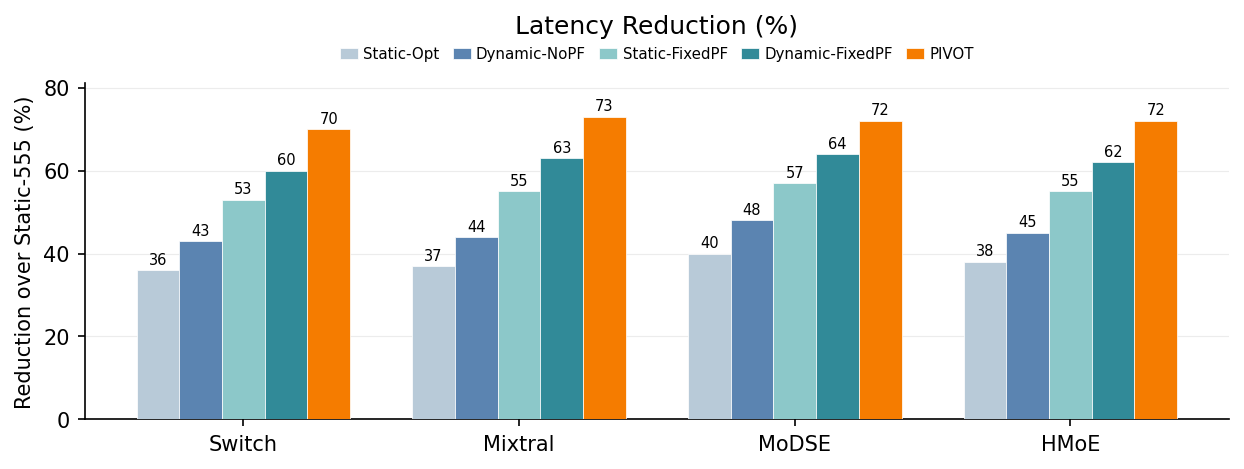

In [22]:
# Fig. 5(a)-1：保留五种可实现方案的跨模型总体性能
fig, ax = plt.subplots(figsize=(8.4, 3.25))
x = np.arange(len(model_order), dtype=float)
bar_width = 0.155
offsets = (np.arange(len(scheme_order)) - (len(scheme_order)-1)/2) * bar_width
for offset, scheme in zip(offsets, scheme_order):
    values = latency_reduction[scheme].to_numpy(dtype=float)
    bars = ax.bar(x + offset, values, width=bar_width,
                  color=scheme_colors[scheme], label=scheme,
                  edgecolor='white', linewidth=.35, zorder=3)
    ax.bar_label(bars, labels=[f'{v:.0f}' for v in values],
                 padding=1.4, fontsize=7)
ax.set_xticks(x, [model_labels[m] for m in model_order])
ax.set_ylabel('Reduction over Static-555 (%)')
ax.set_ylim(0, 81)
ax.set_title('Latency Reduction (%)', pad=24)
ax.grid(axis='y', alpha=.23, linewidth=.55, zorder=0)
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(.5, 1.15),
          frameon=False, fontsize=7.2, handlelength=1.2,
          columnspacing=.9, handletextpad=.35)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_and_show(fig, 'exp5_fig5a_policy_performance')


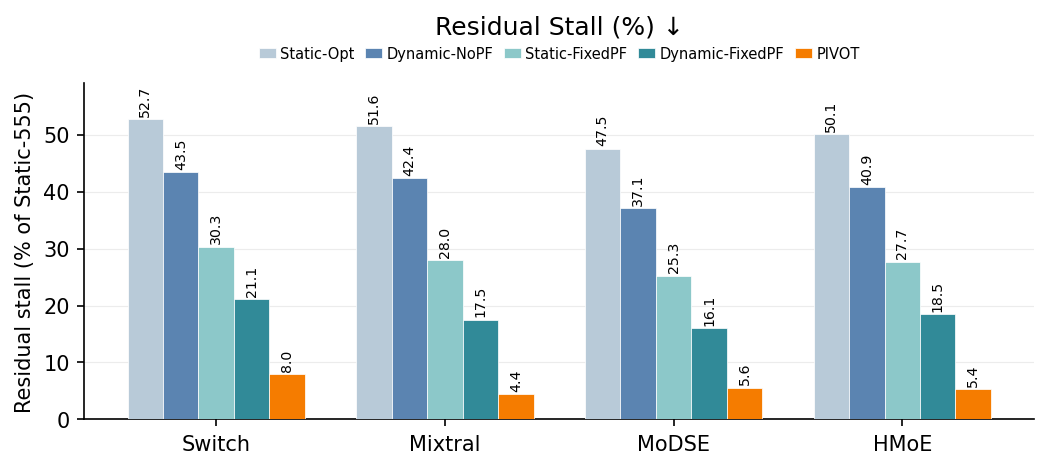

In [23]:
# Fig. 5(a)-2：残余暴露访存停顿（越低越好）
fig, ax = plt.subplots(figsize=(7.1, 3.25))
x = np.arange(len(model_order), dtype=float)
bar_width = 0.155
offsets = (np.arange(len(scheme_order)) - (len(scheme_order)-1)/2) * bar_width
for offset, scheme in zip(offsets, scheme_order):
    values = residual_stall.loc[scheme, model_order].to_numpy(dtype=float)
    bars = ax.bar(x + offset, values, width=bar_width,
                  color=scheme_colors[scheme], label=scheme,
                  edgecolor='white', linewidth=.35, zorder=3)
    ax.bar_label(bars, labels=[f'{v:.1f}' for v in values],
                 padding=1.3, fontsize=6.8, rotation=90)
ax.set_xticks(x, [model_labels[m] for m in model_order])
ax.set_ylabel('Residual stall (% of Static-555)')
ax.set_ylim(0, 59)
ax.set_title('Residual Stall (%) ↓', pad=24)
ax.grid(axis='y', alpha=.23, linewidth=.55, zorder=0)
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(.5, 1.15),
          frameon=False, fontsize=7.0, handlelength=1.15,
          columnspacing=.75, handletextpad=.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_and_show(fig, 'exp5_fig5a_residual_stall')


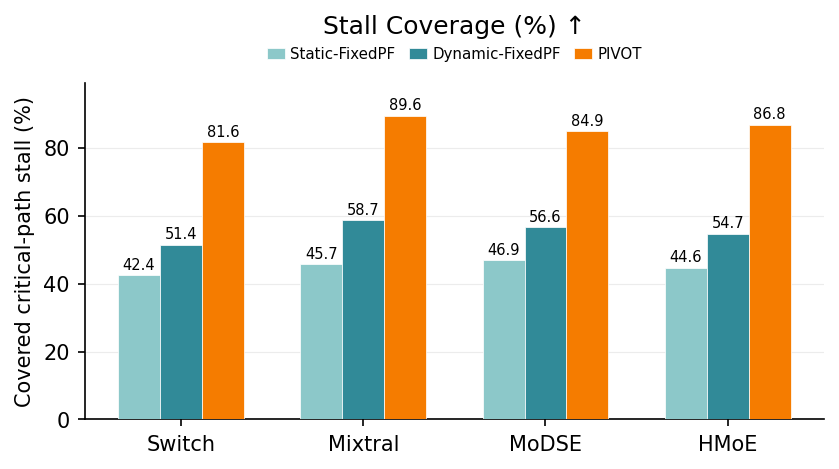

In [24]:
# Fig. 5(a)-3：被消除/隐藏的关键路径访存停顿（越高越好）
fig, ax = plt.subplots(figsize=(5.7, 3.25))
x = np.arange(len(model_order), dtype=float)
bar_width = 0.23
offsets = (np.arange(len(coverage_order)) - (len(coverage_order)-1)/2) * bar_width
for offset, scheme in zip(offsets, coverage_order):
    values = stall_coverage.loc[scheme, model_order].to_numpy(dtype=float)
    bars = ax.bar(x + offset, values, width=bar_width,
                  color=scheme_colors[scheme], label=scheme,
                  edgecolor='white', linewidth=.35, zorder=3)
    ax.bar_label(bars, labels=[f'{v:.1f}' for v in values],
                 padding=1.5, fontsize=7.0)
ax.set_xticks(x, [model_labels[m] for m in model_order])
ax.set_ylabel('Covered critical-path stall (%)')
ax.set_ylim(0, 99)
ax.set_title('Stall Coverage (%) ↑', pad=24)
ax.grid(axis='y', alpha=.23, linewidth=.55, zorder=0)
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(.5, 1.15),
          frameon=False, fontsize=7.2, handlelength=1.2,
          columnspacing=.9, handletextpad=.35)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
save_and_show(fig, 'exp5_fig5a_stall_coverage')
